In [1]:
# Starting the Regression
# import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv("../data/BCF_training.csv")  # Load your dataset here

In [4]:
df.head()

,CAS,SMILES,Experimental value [log(L/kg)],NumAromaticRings,NumHAcceptors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,fr_COO,fr_COO2,fr_halogen,MolWt,MolLogP
0,50-29-3,c1cc(ccc1C(c2ccc(cc2)Cl)C(Cl)(Cl)Cl)Cl,3.605,2,0,5,2,100,0.540334,0.00,85.0370,2.474117,494.044161,0,0,5,354.491,6.4955
1,50-30-6,O=C(O)c1c(cccc1Cl)Cl,-0.222,1,1,4,1,58,0.740184,37.30,43.4213,3.318913,276.242090,1,1,2,191.013,2.6916
2,50-31-7,O=C(O)c1c(ccc(c1Cl)Cl)Cl,0.073,1,1,5,1,64,0.744344,37.30,48.4313,3.428931,335.668528,1,1,3,225.458,3.3450
3,50-32-8,c1ccc2c(c1)cc3ccc4cccc5ccc2c3c45,2.731,5,0,0,0,92,0.243454,0.00,87.6520,2.230840,1069.721887,0,0,0,252.316,5.7372
4,51-28-5,O=[N+]([O-])c1ccc(O)c(c1)[N+](=O)[O-],0.052,1,5,7,2,68,0.548520,106.51,41.4156,3.267052,375.287402,0,0,0,184.107,1.2086


In [6]:
df.columns.to_list()

['CAS',
 'SMILES',
 'Experimental value [log(L/kg)]',
 'NumAromaticRings',
 'NumHAcceptors',
 'NumHeteroatoms',
 'NumRotatableBonds',
 'NumValenceElectrons',
 'qed',
 'TPSA',
 'MolMR',
 'BalabanJ',
 'BertzCT',
 'fr_COO',
 'fr_COO2',
 'fr_halogen',
 'MolWt',
 'MolLogP']

In [7]:
df.shape

(800, 18)

In [9]:
df.isnull().sum()

CAS                               0
SMILES                            0
Experimental value [log(L/kg)]    0
NumAromaticRings                  0
NumHAcceptors                     0
NumHeteroatoms                    0
NumRotatableBonds                 0
NumValenceElectrons               0
qed                               0
TPSA                              0
MolMR                             0
BalabanJ                          0
BertzCT                           0
fr_COO                            0
fr_COO2                           0
fr_halogen                        0
MolWt                             0
MolLogP                           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Experimental value [log(L/kg)],800.0,1.792558,1.332112,-1.700000,0.660750,1.754500,2.812250,5.694000
NumAromaticRings,800.0,1.282500,1.059054,0.000000,1.000000,1.000000,2.000000,7.000000
NumHAcceptors,800.0,2.281250,2.386266,0.000000,1.000000,2.000000,4.000000,20.000000
NumHeteroatoms,800.0,4.265000,3.500013,0.000000,2.000000,4.000000,6.000000,30.000000
NumRotatableBonds,800.0,2.981250,4.017907,0.000000,0.000000,2.000000,4.000000,35.000000
NumValenceElectrons,800.0,84.520000,41.604967,16.000000,56.000000,76.000000,102.500000,342.000000
qed,800.0,0.560874,0.161189,0.036370,0.466675,0.560545,0.664651,0.941210
TPSA,800.0,37.034150,40.486996,0.000000,3.240000,27.690000,54.860000,399.910000
MolMR,800.0,64.191477,29.382869,16.573000,42.495000,60.029150,77.723625,278.243000
BalabanJ,800.0,2.760433,0.704267,1.064135,2.280729,2.740037,3.151898,8.210941


In [12]:
df['Experimental value [log(L/kg)]'].describe()

count    800.000000
mean       1.792558
std        1.332112
min       -1.700000
25%        0.660750
50%        1.754500
75%        2.812250
max        5.694000
Name: Experimental value [log(L/kg)], dtype: float64

<Axes: >

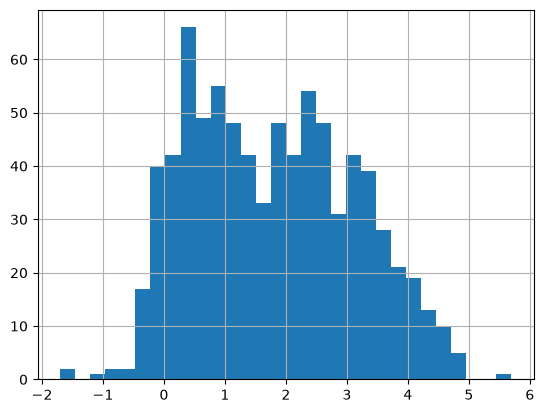

In [13]:
df['Experimental value [log(L/kg)]'].hist(bins=30)

In [ ]:
# Check if halogenated molecules (fr_halogen) drive the higher-BCF cluster in the bimodal distribution
df.groupby(df['Experimental value [log(L/kg)]'] > 2)['fr_halogen'].mean()

Experimental value [log(L/kg)]
False    0.911504
True     1.948276
Name: fr_halogen, dtype: float64

In [ ]:
# Inspect the lowest-BCF outliers for data quality issues before trusting them
df[df['Experimental value [log(L/kg)]'] < -1]


,CAS,SMILES,Experimental value [log(L/kg)],NumAromaticRings,NumHAcceptors,NumHeteroatoms,NumRotatableBonds,NumValenceElectrons,qed,TPSA,MolMR,BalabanJ,BertzCT,fr_COO,fr_COO2,fr_halogen,MolWt,MolLogP
624,01/02/1918,O=C(O)c1nc(c(c(N)c1Cl)Cl)Cl,-1.700,1,3,7,1,70,0.739877,76.21,50.6387,3.497381,380.632381,1,1,3,241.461,2.3222
707,30560-19-1,O=C(NP(=O)(OC)SC)C,-1.523,0,4,6,3,60,0.668589,55.40,41.9472,4.074119,163.885639,0,0,0,183.169,1.2400


In [ ]:
# Check if carboxylic acid groups (fr_COO/fr_COO2) are associated with the lower-BCF cluster
df.groupby(df['Experimental value [log(L/kg)]'] > 2)[['fr_COO', 'fr_COO2']].mean()

,fr_COO,fr_COO2
Experimental value [log(L/kg)],,
False,0.123894,0.123894
True,0.002874,0.002874


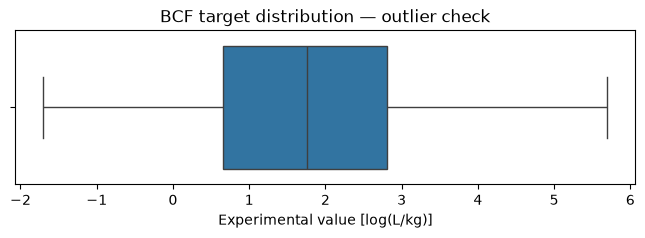

In [17]:
# Check for outliers using boxplot
plt.figure(figsize=(8, 2))
sns.boxplot(x=df['Experimental value [log(L/kg)]'])
plt.title('BCF target distribution — outlier check')
plt.show()

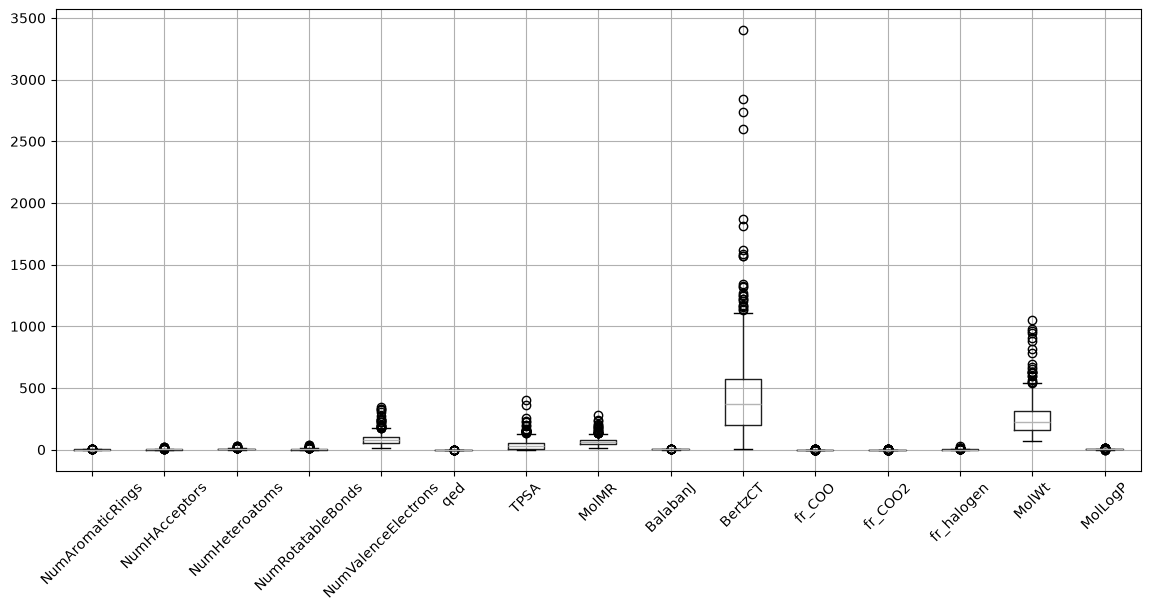

In [ ]:
# Check for outliers in each feature using boxplot
X_check = df.drop(columns=['CAS', 'SMILES', 'Experimental value [log(L/kg)]'])
X_check.boxplot(figsize=(14, 6), rot=45)
plt.show()

In [19]:
# Check for the largest contributor for BertzCT (complexity) to see if it is driving the higher-BCF cluster
df.nlargest(5, 'BertzCT')[['SMILES', 'BertzCT', 'MolWt', 'Experimental value [log(L/kg)]']]

,SMILES,BertzCT,MolWt,Experimental value [log(L/kg)]
575,O=S(=O)(O)c7cccc6c7(cc(N=Nc1ccc(cc1C)Nc2nc(nc(...,3401.561623,979.026,0.498
486,O=S(=O)(O)c6cc5ccc(O)c(N=Nc1ccc(cc1C)c4ccc(N=N...,2841.806224,786.866,1.851
523,O=S(=O)(O)OCCS(=O)(=O)c4ccc(N=Nc1c(O)c3c(cc1S(...,2739.039117,903.904,0.541
518,O=S(=O)(O)c5cc(ccc5(C=Cc1ccc(cc1S(=O)(=O)O)Nc2...,2603.633976,880.970,0.960
766,O([Sn](CC(c1ccccc1)(C)C)(CC(c2ccccc2)(C)C)CC(c...,1869.054490,1052.705,2.863


In [20]:
# X and y for regression
X = df.drop(columns=['CAS', 'SMILES', 'Experimental value [log(L/kg)]'])
y = df['Experimental value [log(L/kg)]']
X.shape

(800, 15)

In [21]:
# Model evaluation starting with Linear regression

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

In [22]:
# CV evaluation due to smaller dataset
cv = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(lr_pipe, X, y, cv=cv, scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2']) 


In [23]:
print('RMSE:', -scores['test_neg_root_mean_squared_error'].mean(), '±', scores['test_neg_root_mean_squared_error'].std())
print('MAE: ', -scores['test_neg_mean_absolute_error'].mean(), '±', scores['test_neg_mean_absolute_error'].std())
print('R²:  ', scores['test_r2'].mean(), '±', scores['test_r2'].std())

RMSE: 0.936797126824475 ± 0.08529732231091776
MAE:  0.7446847769440612 ± 0.04357929940025595
R²:   0.4895431562205027 ± 0.13332431350545032


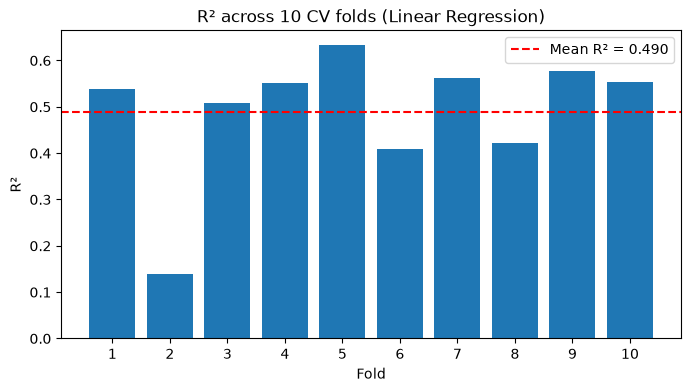

In [24]:
# R2 plot across the 10 fold
plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), scores['test_r2'])
plt.axhline(scores['test_r2'].mean(), color='red', linestyle='--', label=f"Mean R² = {scores['test_r2'].mean():.3f}")
plt.xlabel('Fold')
plt.ylabel('R²')
plt.title('R² across 10 CV folds (Linear Regression)')
plt.xticks(range(1, 11))
plt.legend()
plt.show()

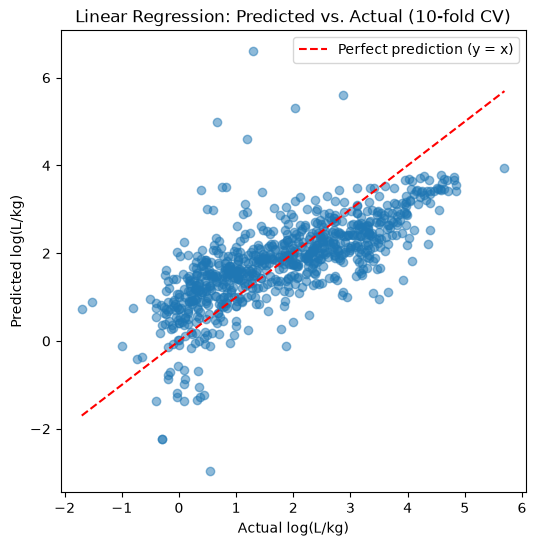

In [25]:
from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(lr_pipe, X, y, cv=cv)

plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred_cv, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction (y = x)')
plt.xlabel('Actual log(L/kg)')
plt.ylabel('Predicted log(L/kg)')
plt.title('Linear Regression: Predicted vs. Actual (10-fold CV)')
plt.legend()
plt.show()

In [26]:
# Check for overfitting and underfitting
scores = cross_validate(lr_pipe, X, y, cv=cv, scoring=['neg_root_mean_squared_error', 'r2'], return_train_score=True)

print('Train R²:     ', scores['train_r2'].mean())
print('Validation R²:', scores['test_r2'].mean())

Train R²:      0.544129691695743
Validation R²: 0.4895431562205027


In [27]:
# KNN Regression
from sklearn.neighbors import KNeighborsRegressor

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', KNeighborsRegressor())
])

scores = cross_validate(knn_pipe, X, y, cv=cv,
                         scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
                         return_train_score=True)

print('RMSE:', -scores['test_neg_root_mean_squared_error'].mean(), '±', scores['test_neg_root_mean_squared_error'].std())
print('MAE: ', -scores['test_neg_mean_absolute_error'].mean(), '±', scores['test_neg_mean_absolute_error'].std())
print('Train R²:     ', scores['train_r2'].mean())
print('Validation R²:', scores['test_r2'].mean(), '±', scores['test_r2'].std())

RMSE: 0.7644049652552221 ± 0.08445899030395053
MAE:  0.57213125 ± 0.060395869211499066
Train R²:      0.7860906649446073
Validation R²: 0.662475810883749 ± 0.07416885224888876


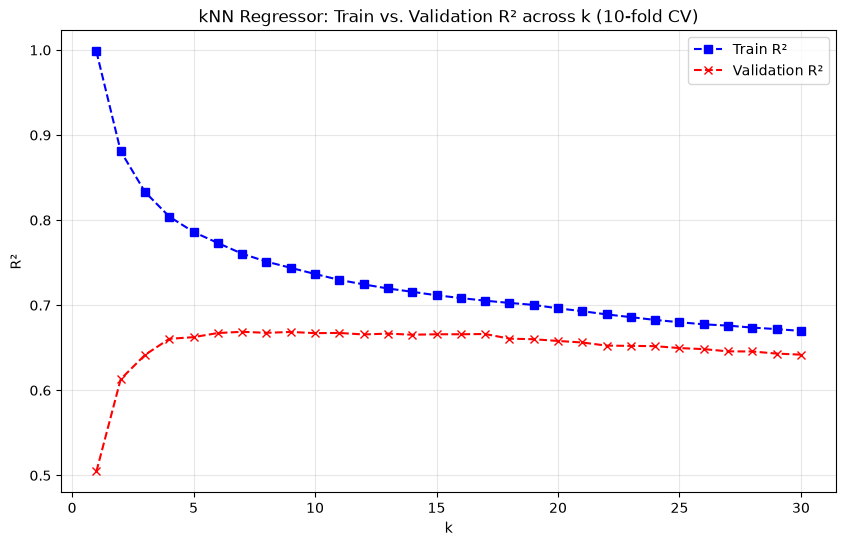

Best k: 7 | Validation R² at best k: 0.6687732945815364


In [29]:
# Sweeping for best K values for KNN regression
k_values = range(1, 31)

train_r2 = []
valid_r2 = []

for k in k_values:
    knn_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('reg', KNeighborsRegressor(n_neighbors=k))
    ])
    scores = cross_validate(knn_pipe, X, y, cv=cv, scoring='r2', return_train_score=True)
    train_r2.append(scores['train_score'].mean())
    valid_r2.append(scores['test_score'].mean())

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_r2, 'bs--', label='Train R²')
plt.plot(k_values, valid_r2, 'rx--', label='Validation R²')
plt.xlabel('k')
plt.ylabel('R²')
plt.title('kNN Regressor: Train vs. Validation R² across k (10-fold CV)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_k = k_values[np.argmax(valid_r2)]
print('Best k:', best_k, '| Validation R² at best k:', max(valid_r2))

In [30]:
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', KNeighborsRegressor(n_neighbors=7))
])
scores = cross_validate(knn_pipe, X, y, cv=cv,
                         scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
                         return_train_score=True)

print('RMSE:', -scores['test_neg_root_mean_squared_error'].mean(), '±', scores['test_neg_root_mean_squared_error'].std())
print('MAE: ', -scores['test_neg_mean_absolute_error'].mean(), '±', scores['test_neg_mean_absolute_error'].std())
print('Train R²:     ', scores['train_r2'].mean())
print('Validation R²:', scores['test_r2'].mean(), '±', scores['test_r2'].std())

RMSE: 0.7562414733778571 ± 0.08776927539573315
MAE:  0.5695258928571428 ± 0.0693951255936203
Train R²:      0.7605394820277487
Validation R²: 0.6687732945815364 ± 0.0774954117872809


In [31]:
# Ranfom Forest Regression and XGBoost Regression
models = {
    'Random Forest': Pipeline([('scaler', StandardScaler()), ('reg', RandomForestRegressor(random_state=42))]),
    'XGBoost': Pipeline([('scaler', StandardScaler()), ('reg', XGBRegressor(random_state=42))]),
}

results = {}
for name, pipe in models.items():
    scores = cross_validate(pipe, X, y, cv=cv,
                             scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'],
                             return_train_score=True)
    results[name] = scores

In [34]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE': [-scores['test_neg_root_mean_squared_error'].mean() for scores in results.values()],
    'MAE': [-scores['test_neg_mean_absolute_error'].mean() for scores in results.values()],
    'Train R²': [scores['train_r2'].mean() for scores in results.values()],
    'Validation R²': [scores['test_r2'].mean() for scores in results.values()]
})
results_df

,Model,RMSE,MAE,Train R²,Validation R²
0,Random Forest,0.691448,0.508583,0.960101,0.721311
1,XGBoost,0.725487,0.529234,0.998617,0.692914


In [35]:
results

{'Random Forest': {'fit_time': array([0.67760277, 0.47836113, 0.47783041, 0.51651478, 0.51644516,
         0.50922823, 0.4896338 , 0.47363663, 0.53273678, 0.4888823 ]),
  'score_time': array([0.01646328, 0.00771976, 0.        , 0.02602291, 0.01679015,
         0.01843524, 0.012748  , 0.01844668, 0.01664758, 0.01673841]),
  'test_neg_root_mean_squared_error': array([-0.88921444, -0.70735097, -0.7582471 , -0.72900863, -0.77198407,
         -0.6916954 , -0.54306922, -0.750895  , -0.57789264, -0.49512045]),
  'train_neg_root_mean_squared_error': array([-0.26027049, -0.26495325, -0.2631377 , -0.26364112, -0.26562358,
         -0.26235263, -0.2696718 , -0.2676021 , -0.27093613, -0.27063375]),
  'test_neg_mean_absolute_error': array([-0.68062928, -0.49718742, -0.57228797, -0.53101782, -0.5681129 ,
         -0.50124565, -0.4018567 , -0.53212043, -0.41851439, -0.38285391]),
  'train_neg_mean_absolute_error': array([-0.18692018, -0.19333915, -0.18807219, -0.18982307, -0.19095096,
         -0.190

The training r2 and the validation r2 are very different, so bot the models are overfitting by a lot. Need to tune them. 